## Logistics Route Profitability Analysis

This project analyzes route-level profitability and route consistency in a logistics network. The goal is to identify which routes generate the most value, which ones consistently lose money, and which routes show unstable performance.

### Objective
Identify which routes generate real profitability after operational costs and which ones are structurally unprofitable.

### Key Questions
- Are high-demand routes always profitable?
- Which routes consistently lose money?
- Can we segment routes based on performance?

### Key Result
A small number of routes are structurally unprofitable, while most of the network operates efficiently. Profitability is driven by unit economics rather than volume.

## Data Overview

The dataset represents a logistics operation over a 3-year period (2022–2024), covering key aspects of fleet management, shipments, and operational performance.

It includes multiple interconnected tables that simulate a real-world relational database, allowing analysis across different dimensions such as routes, drivers, costs, and operational events.

### Key Data Entities

* **Loads**: Shipment-level data including revenue, customer, and route information
* **Trips**: Execution-level data capturing actual trip performance (duration, fuel usage, etc.)
* **Routes**: Origin-destination pairs with distance and structural information
* **Drivers**: Driver details and performance-related attributes
* **Fuel Purchases**: Fuel transactions associated with trips
* **Delivery Events**: Operational events such as pickups, deliveries, and delays
* **Safety Incidents**: Records of accidents or operational issues
* **Maintenance Records**: Truck service history and associated costs

### Data Relationships

The dataset follows a relational structure where:

* Each **load** is linked to a **route** and a **customer**
* Each **trip** represents the execution of a load and is linked to a **driver**, **truck**, and **trailer**
* Operational data such as **fuel purchases**, **delivery events**, and **incidents** are tied to individual trips

This structure enables analysis from planned operations (loads/routes) to actual performance (trips and events).

### Data Considerations

* Some datasets may contain missing or inconsistent values
* Aggregated tables (e.g., monthly metrics) are excluded from detailed analysis to maintain granularity
* Cost calculations are primarily based on fuel data, as other cost components may not be fully available


## SET UP: Importing all libraries and databases to analyse

In [1]:
# Libraries for data processing, SQL analysis, and visualization

# Data handling
import pandas as pd
import numpy as np

# SQL
import sqlite3

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
## Import all CSV 
base_path = "/kaggle/input/datasets/yogape/logistics-operations-database/"
loads = pd.read_csv(base_path + "loads.csv")
routes = pd.read_csv(base_path + "routes.csv")
trips = pd.read_csv(base_path + "trips.csv")
fuel = pd.read_csv(base_path + "fuel_purchases.csv")

In [3]:
# DB to memory
conn = sqlite3.connect(':memory:')

#Load csv to sql
loads.to_sql('loads', conn, index=False)
routes.to_sql('routes', conn, index=False)
trips.to_sql('trips', conn, index=False)
fuel.to_sql('fuel', conn, index=False)

#Verification
pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)

#Visualize all columns
print(loads.columns)
print(routes.columns)
print(trips.columns)
print(fuel.columns)

Index(['load_id', 'customer_id', 'route_id', 'load_date', 'load_type',
       'weight_lbs', 'pieces', 'revenue', 'fuel_surcharge',
       'accessorial_charges', 'load_status', 'booking_type'],
      dtype='object')
Index(['route_id', 'origin_city', 'origin_state', 'destination_city',
       'destination_state', 'typical_distance_miles', 'base_rate_per_mile',
       'fuel_surcharge_rate', 'typical_transit_days'],
      dtype='object')
Index(['trip_id', 'load_id', 'driver_id', 'truck_id', 'trailer_id',
       'dispatch_date', 'actual_distance_miles', 'actual_duration_hours',
       'fuel_gallons_used', 'average_mpg', 'idle_time_hours', 'trip_status'],
      dtype='object')
Index(['fuel_purchase_id', 'trip_id', 'truck_id', 'driver_id', 'purchase_date',
       'location_city', 'location_state', 'gallons', 'price_per_gallon',
       'total_cost', 'fuel_card_number'],
      dtype='object')


In [4]:
#Let's see first 5 rows from loads
query = """
SELECT *
FROM loads
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,3045.23,406.72,100,Completed,Spot
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,1224.48,98.61,0,Completed,Dedicated
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,7171.12,792.88,0,Completed,Spot
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,1308.20,141.33,50,Completed,Spot
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,3317.18,738.48,0,Completed,Spot


## Route Profitability Analysis

### Business Question
Which routes are truly profitable after accounting for operational costs?

---

### Revenue

From the `loads` table, we use:

- revenue  
- fuel_surcharge  
- accessorial_charges  

Total revenue is defined as:

**total_revenue = revenue + fuel_surcharge + accessorial_charges**

---

### Costs

Operational cost is estimated using fuel expenses.

Fuel data comes from the `fuel_purchases` table, linked to each trip. 

Due to data limitations, fuel cost is used as a proxy for total operational cost. Other components such as driver salaries, maintenance, and depreciation are not included. Therefore, profitability should be interpreted as a partial estimate.

---

### Profit

**profit = total_revenue - fuel_cost**

---

### Level of Analysis

All metrics are aggregated at the **route level**, combining results from all trips assigned to each route.

In [5]:
query = """
SELECT 
    l.load_id,
    l.route_id,
    t.trip_id,
    r.origin_city, 
    r.origin_state, 
    r.destination_city, 
    r.destination_state,
    (l.revenue + l.fuel_surcharge + l.accessorial_charges) AS total_revenue,
    f.fuel_cost,
    (l.revenue + l.fuel_surcharge + l.accessorial_charges) - f.fuel_cost AS profit
FROM loads AS l
JOIN trips AS t
    ON l.load_id = t.load_id
JOIN routes AS r
    ON l.route_id = r.route_id
JOIN (
    SELECT 
        trip_id,
        SUM(total_cost) AS fuel_cost
    FROM fuel
    GROUP BY trip_id
) AS f
    ON t.trip_id = f.trip_id
WHERE t.trip_status = 'Completed'
"""

route_profitability = pd.read_sql_query(query, conn)
route_profitability.to_sql('base_table', conn, index=False, if_exists='replace')
route_profitability.head()

,load_id,route_id,trip_id,origin_city,origin_state,destination_city,destination_state,total_revenue,fuel_cost,profit
0,LOAD00000001,RTE00019,TRIP00000001,Houston,TX,Detroit,MI,3551.95,779.45,2772.50
1,LOAD00000002,RTE00058,TRIP00000002,Kansas City,MO,Indianapolis,IN,1323.09,752.70,570.39
2,LOAD00000003,RTE00048,TRIP00000003,Columbus,OH,Portland,OR,7964.00,3796.39,4167.61
3,LOAD00000005,RTE00020,TRIP00000005,Houston,TX,Seattle,WA,4055.66,512.53,3543.13
4,LOAD00000006,RTE00004,TRIP00000006,Chicago,IL,Portland,OR,4041.01,3311.07,729.94


## 1. Overview - Volume and Costs

In [6]:

total_routes = route_profitability['route_id'].nunique()
total_trips = route_profitability['trip_id'].nunique()

total_revenue = route_profitability['total_revenue'].sum()
total_cost = route_profitability['fuel_cost'].sum()
total_profit = route_profitability['profit'].sum()

avg_profit = route_profitability['profit'].mean()

print(f"There are {total_routes} unique routes and {total_trips} completed trips.")

print(f"Total revenue is ${total_revenue:,.0f}, with total fuel costs of ${total_cost:,.0f}, resulting in a total profit of ${total_profit:,.0f}.")

print(f"On average, each trip generates ${avg_profit:,.2f} in profit.")

query_top_10_profit = """
SELECT
    route_id || ' - ' || origin_city || ' → ' || destination_city as route_name,
    count(trip_id) as total_trips,
    SUM(total_revenue) AS sum_revenue,
    SUM(fuel_cost) AS sum_cost,
    SUM(profit) AS sum_profit,
    AVG(profit) AS avg_profit_per_trip
    
FROM base_table
GROUP BY route_id
ORDER BY SUM(profit) DESC
"""
route_profitability_summary_profit = pd.read_sql_query(query_top_10_profit, conn)
print(route_profitability_summary_profit.head(10))

There are 58 unique routes and 76939 completed trips.
Total revenue is $268,825,737, with total fuel costs of $95,592,992, resulting in a total profit of $173,232,745.
On average, each trip generates $2,251.56 in profit.
                          route_name  total_trips  sum_revenue    sum_cost  \
0    RTE00044 - Charlotte → Portland         1243   9906968.09  1553387.90   
1     RTE00029 - Seattle → Charlotte         1340   9983204.57  1707728.59   
2     RTE00048 - Columbus → Portland         1366   9784109.88  1665771.08   
3  RTE00016 - Philadelphia → Seattle         1311   9719627.41  1608382.40   
4  RTE00012 - Phoenix → Philadelphia         1352   9466659.47  1669546.56   
5  RTE00046 - Columbus → Los Angeles         1381   9341073.53  1721908.05   
6     RTE00042 - Charlotte → Seattle         1303   8877736.05  1615945.96   
7  RTE00030 - Seattle → Indianapolis         1304   7953406.61  1644240.20   
8   RTE00003 - Chicago → Los Angeles         1344   7726493.93  1668535.89   

Top-performing routes are not only driven by volume, as trip counts are relatively consistent across routes (~1300 trips each).

The key differentiator is profitability per trip, which varies significantly across routes (from ~$4.5k to ~$6.7k per trip).

This suggests that route efficiency, pricing, or operational factors play a major role in determining overall profitability.

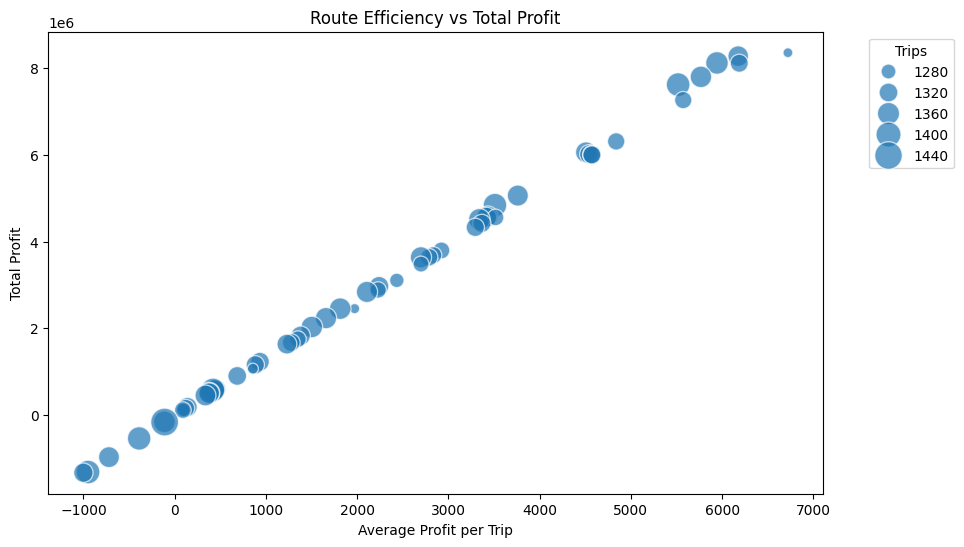

In [7]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=route_profitability_summary_profit,  
    x="avg_profit_per_trip",
    y="sum_profit",
    size="total_trips",
    sizes=(50, 400),
    alpha=0.7
)

plt.title("Route Efficiency vs Total Profit")
plt.xlabel("Average Profit per Trip")
plt.ylabel("Total Profit")

plt.legend(title="Trips", bbox_to_anchor=(1.05, 1))
plt.show()

## Top 5 Most Efficient Routes

In [8]:
query_top_5_efficiency = """
SELECT
    route_id || ' - ' || origin_city || ' → ' || destination_city as route_name,
    count(trip_id) as total_trips,
    SUM(total_revenue) AS sum_revenue,
    SUM(fuel_cost) AS sum_cost,
    SUM(profit) AS sum_profit,
    AVG(profit) AS avg_profit_per_trip
    
FROM base_table
GROUP BY route_id
ORDER BY AVG(profit) DESC
LIMIT 5;
"""
route_profitability_summary_efficiency = pd.read_sql_query(query_top_5_efficiency, conn)
print(route_profitability_summary_efficiency)

                          route_name  total_trips  sum_revenue    sum_cost  \
0    RTE00044 - Charlotte → Portland         1243   9906968.09  1553387.90   
1  RTE00016 - Philadelphia → Seattle         1311   9719627.41  1608382.40   
2     RTE00029 - Seattle → Charlotte         1340   9983204.57  1707728.59   
3     RTE00048 - Columbus → Portland         1366   9784109.88  1665771.08   
4  RTE00012 - Phoenix → Philadelphia         1352   9466659.47  1669546.56   

   sum_profit  avg_profit_per_trip  
0  8353580.19          6720.498946  
1  8111245.01          6187.067132  
2  8275475.98          6175.728343  
3  8118338.80          5943.146999  
4  7797112.91          5767.095348  


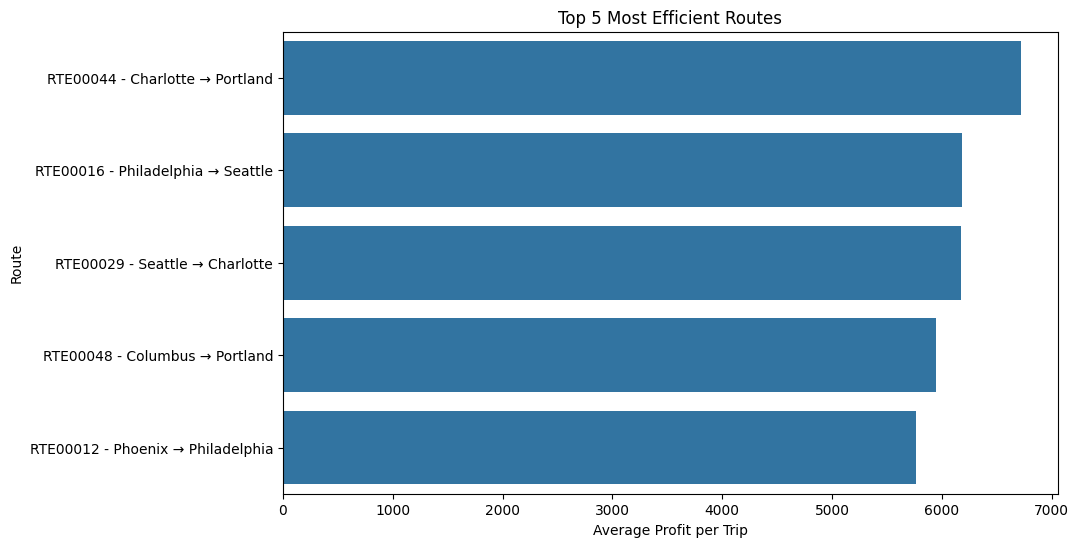

In [9]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=route_profitability_summary_efficiency,
    x="avg_profit_per_trip",
    y="route_name"
)

plt.title("Top 5 Most Efficient Routes")
plt.xlabel("Average Profit per Trip")
plt.ylabel("Route")

plt.show()


There is a strong alignment between total profitability and efficiency across routes. 

The most profitable routes are also among the most efficient, suggesting that performance is driven by both high demand and strong margins per trip.

This indicates a well-optimized core network, where key routes are both frequently used and economically efficient.

## Bottom 10 Profit

In [10]:
query_bottom_10_profit = """
SELECT
    route_id || ' - ' || origin_city || ' → ' || destination_city as route_name,
    count(trip_id) as total_trips,
    SUM(total_revenue) AS sum_revenue,
    SUM(fuel_cost) AS sum_cost,
    SUM(profit) AS sum_profit,
    AVG(profit) AS avg_profit_per_trip
    
FROM base_table
GROUP BY route_id
ORDER BY SUM(profit)
LIMIT 10;
"""
route_profitability_summary_botprofit = pd.read_sql_query(query_bottom_10_profit, conn)
print(route_profitability_summary_botprofit)

                              route_name  total_trips  sum_revenue  \
0     RTE00010 - New York → Philadelphia         1326    314536.59   
1     RTE00015 - Philadelphia → New York         1381    470892.32   
2          RTE00033 - Portland → Seattle         1344    694974.79   
3     RTE00036 - Las Vegas → Los Angeles         1378   1163139.46   
4     RTE00047 - Columbus → Philadelphia         1444   1626824.49   
5         RTE00011 - New York → Columbus         1354   1524874.55   
6           RTE00022 - Houston → Memphis         1297   1709482.18   
7  RTE00058 - Kansas City → Indianapolis         1271   1708811.67   
8            RTE00013 - Phoenix → Denver         1308   1772421.60   
9           RTE00001 - Atlanta → Chicago         1326   1792756.72   

     sum_cost  sum_profit  avg_profit_per_trip  
0  1641529.05 -1326992.46         -1000.748462  
1  1782066.61 -1311174.29          -949.438298  
2  1662837.92  -967863.13          -720.136257  
3  1699724.63  -536585.17        

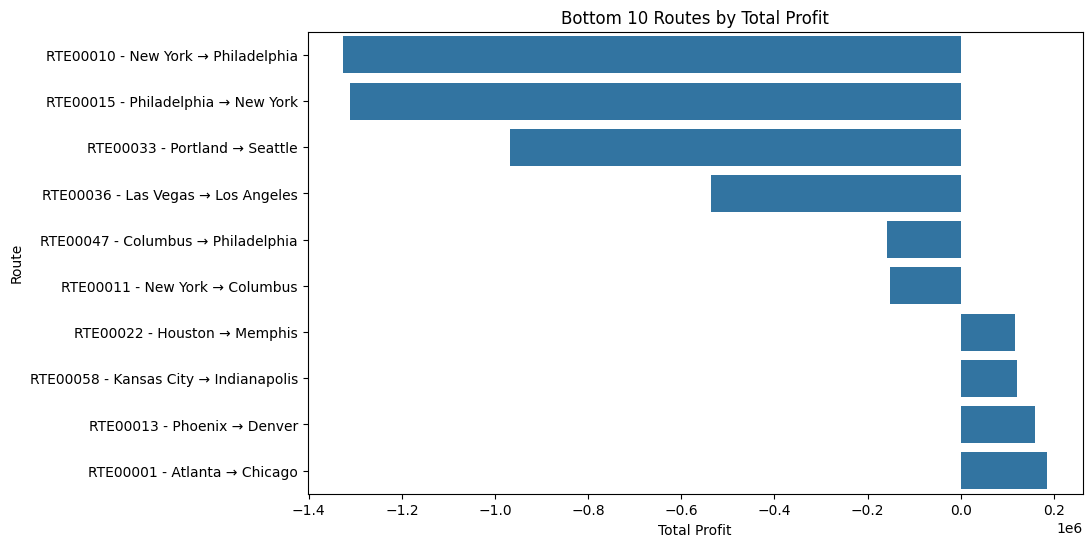

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=route_profitability_summary_botprofit,
    x="sum_profit",
    y="route_name"
)

plt.title("Bottom 10 Routes by Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Route")

plt.show()

Some routes show significant and consistent losses, with negative profit per trip reaching up to -$1,000.

These losses are not driven by low volume, as these routes operate with a similar number of trips compared to top-performing routes.

This indicates a structural issue in pricing, cost management, or route efficiency, where each additional trip increases total losses.

Some underperforming routes are unprofitable in both directions and connect major cities, suggesting that the issue is structural rather than directional.

This indicates that high-demand corridors are not necessarily profitable, likely due to factors such as strong competition, pricing pressure, or higher operational costs(traffic congestions, etc).

To sum up, the main issues in operational performance are driven by routes with negative profitability.

This suggests the need to further analyze whether these routes are consistently unprofitable or if their performance is volatile.

# Performance Analysis 

In [12]:
# ROUTES and creating categories

query_consistency = """
SELECT *,
    CASE 
        WHEN pct_unprofitable_trips >= 80 THEN 'Unprofitable'
        WHEN pct_unprofitable_trips >= 50 THEN 'Volatile'
        WHEN pct_unprofitable_trips < 10 THEN 'High Performing'
        ELSE 'Medium Performance'
    END AS category
FROM (
    SELECT
        route_id || ' - ' || origin_city || ' → ' || destination_city AS route_name,
        COUNT(trip_id) AS total_trips,
        SUM(CASE WHEN profit < 0 THEN 1 ELSE 0 END) AS unprofitable_trips,
        SUM(CASE WHEN profit < 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(trip_id) AS pct_unprofitable_trips
    FROM base_table
    GROUP BY route_id
)
ORDER BY pct_unprofitable_trips DESC
"""

route_consistency = pd.read_sql_query(query_consistency, conn)

In [13]:
print(route_consistency[route_consistency['category']=='Unprofitable'])

                           route_name  total_trips  unprofitable_trips  \
0  RTE00010 - New York → Philadelphia         1326                1290   
1  RTE00015 - Philadelphia → New York         1381                1295   
2       RTE00033 - Portland → Seattle         1344                1152   

   pct_unprofitable_trips      category  
0               97.285068  Unprofitable  
1               93.772629  Unprofitable  
2               85.714286  Unprofitable  


A small group of routes shows extremely high levels of unprofitability, with more than 85–97% of trips generating losses.

These routes are structurally inefficient, as they lose money in nearly every operation. Given their high volume, each additional trip increases total losses, making them critical areas for immediate intervention.

Interestingly, some of these routes are bidirectional (e.g., New York ↔ Philadelphia), suggesting that the issue is not directional but related to the overall economics of the route.

In [14]:
print(route_consistency.loc[route_consistency['category'] == 'Volatile'])

                           route_name  total_trips  unprofitable_trips  \
3  RTE00036 - Las Vegas → Los Angeles         1378                 889   
4  RTE00047 - Columbus → Philadelphia         1444                 724   

   pct_unprofitable_trips  category  
3               64.513788  Volatile  
4               50.138504  Volatile  


Some routes exhibit moderate levels of unprofitability (50–65%), indicating inconsistent performance.

These routes are not structurally unprofitable but show significant variability, suggesting potential operational inefficiencies, cost fluctuations, or pricing inconsistencies.

Unlike structurally unprofitable routes, these may benefit from targeted optimization rather than complete redesign.

In [15]:
print(route_consistency.loc[route_consistency['category'] == 'High Performing'])

                               route_name  total_trips  unprofitable_trips  \
21  RTE00017 - Philadelphia → Minneapolis         1331                 114   
22          RTE00035 - Las Vegas → Dallas         1308                  85   
23     RTE00057 - Kansas City → Charlotte         1326                  73   
24       RTE00039 - Minneapolis → Atlanta         1296                  61   
25          RTE00043 - Charlotte → Denver         1352                  55   
26           RTE00027 - Detroit → Houston         1353                  35   
27       RTE00014 - Phoenix → Kansas City         1349                  33   
28              RTE00023 - Miami → Dallas         1245                  29   
29   RTE00054 - Kansas City → Los Angeles         1327                  19   
30        RTE00024 - Miami → Philadelphia         1348                  18   
31           RTE00019 - Houston → Detroit         1294                  14   
32       RTE00041 - Minneapolis → Houston         1276          

A large number of routes show very low levels of unprofitability, with many achieving near-perfect performance (0–1% of unprofitable trips).

These routes demonstrate strong operational efficiency and stable margins, making them the most reliable and scalable parts of the network.

They represent the core of the business and should be prioritized for growth and replication of best practices.

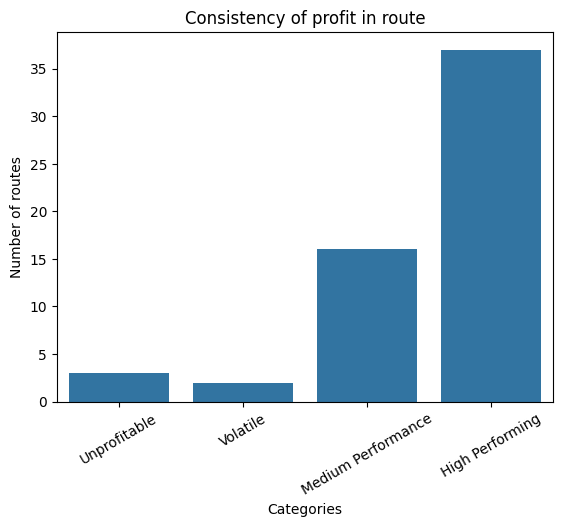

In [16]:
sns.countplot(data=route_consistency, x="category")
plt.title("Consistency of profit in route")
plt.xlabel("Categories")
plt.ylabel("Number of routes")
plt.xticks(rotation=30)
plt.show()

## Key Insights

- Profitability is highly concentrated: a small number of routes generate strong performance, while a few routes consistently destroy value.
- Structural losses are not driven by low volume, but by poor unit economics, as seen in routes with >80% unprofitable trips.
- High-demand routes connecting major cities are not necessarily profitable, see New York Philadelphia.
- There is a clear segmentation between high-performing, volatile, and structurally unprofitable routes.

## Recommendations

- **Eliminate or redesign structurally unprofitable routes (>80%)**, focusing on pricing, cost structure, or strategic relevance.
- **Optimize volatile routes (50–80%)** by identifying drivers of variability (fuel costs, pricing, operational inefficiencies).
- **Scale high-performing routes (<10%)**, increasing volume and replicating their operational and pricing strategies across similar routes.

## Final Conclusion

Profitability in this network is primarily driven by route-level unit economics rather than volume.

Targeted actions on underperforming routes could significantly improve overall profitability without requiring additional demand.

## Future Work
- Analyze driver performance impact on route profitability.
- Evaluate maintenance costs influence on margins .